# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [2]:
# importar librerías

# Análisis de datos y manipulación
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística (SciPy y Statsmodels)
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, pointbiserialr, fisher_exact, ttest_ind, levene, shapiro
from statsmodels.stats.proportion import proportions_ztest

# Utilidades
import re

#Sql
from sqlalchemy import create_engine

In [3]:
# cargar archivos
orders = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv")
catalog = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv")
marketing = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")

In [4]:
# explorar datasets
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [5]:
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [6]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [7]:
# tu código aquí
orders.info()

#Auditoría y Preparación
# 1. Convertir fecha
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')

# 2. Revisar duplicados
print(f"Duplicados encontrados: {orders.duplicated().sum()}")
orders = orders.drop_duplicates()

# 3. Análisis de nulos en columnas numéricas
# Si monto_total existe pero cantidad o precio son nulos, hay que investigar
nulos_financieros = orders[orders['cantidad'].isna() | orders['precio_unitario'].isna()]
print(f"\nRegistros con nulos en cantidad o precio: {len(nulos_financieros)}")

# 4. Estandarizar nombres de columnas (snake_case)
orders.columns = [col.lower().replace(" ", "_") for col in orders.columns]

# 5. Revisar variables categóricas
print("\nValores únicos en 'pais':", orders['pais'].unique())
print("Valores únicos en 'dispositivo':", orders['dispositivo'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  str    
 1   id_usuario          25100 non-null  str    
 2   fecha_hora_pedido   25100 non-null  str    
 3   pais                24800 non-null  str    
 4   dispositivo         25080 non-null  str    
 5   fuente_referencia   25070 non-null  str    
 6   nombre_producto     25070 non-null  str    
 7   categoria_producto  25020 non-null  str    
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), str(8)
memory usage: 2.3 MB
Duplicados encontrados: 100

Registros con nulos en cantidad o precio: 50

Valores únicos en 'pais': <StringArray>
['Argentina', 'Mexico', 'Colombia', 'mexico', 'colomb

In [8]:
#Limpieza y Consistencia
# 1. Eliminar registros donde no tenemos información financiera (cantidad o precio nulos)
orders = orders.dropna(subset=['cantidad', 'precio_unitario'])

# 2. Eliminar registros con valores inválidos (<= 0)
# Como son solo 4, mejor quitarlos para no tener problemas en cálculos de ROI/Margen
orders = orders[orders['cantidad'] > 0]
orders = orders[orders['monto_total'] > 0]

# 3. Normalizar columnas categoricas
normalizar_columnas = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
for col in normalizar_columnas:
    orders[col] = orders[col].str.lower().str.capitalize()

# 4. Rellenar nulos en 'dispositivo' y 'fuente_referencia' con 'desconocido'
# Esto evita perder filas si el usuario no tiene esa info
orders['dispositivo'] = orders['dispositivo'].fillna('desconocido')
orders['fuente_referencia'] = orders['fuente_referencia'].fillna('desconocido')

# 5. Verificación final
print("Nulos totales tras limpieza:")
print(orders.isna().sum())
print(f"\nDimensiones finales: {orders.shape}")

#Limpieza final de categóricas en 'orders'
cols_to_fill = ['pais', 'nombre_producto', 'categoria_producto']
orders[cols_to_fill] = orders[cols_to_fill].fillna('desconocido')

# Verificación final
print("Nulos tras limpieza final:")

print(orders.isna().sum())

Nulos totales tras limpieza:
id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo             0
fuente_referencia       0
nombre_producto        30
categoria_producto     30
cantidad                0
precio_unitario         0
monto_descuento         0
monto_total             0
dtype: int64

Dimensiones finales: (24946, 12)
Nulos tras limpieza final:
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64


In [9]:
catalog.info()
#1. Estandarizar nombres de columnas con Snake case
catalog.columns = [col.lower().replace(" ", "_") for col in catalog.columns]

# 2. Normalizar texto en columnas categóricas
# Iteramos sobre la lista de columnas
cols_to_norm = ['nombre_producto', 'categoria_producto', 'proveedor']

for col in cols_to_norm:
    catalog[col] = catalog[col].str.lower().str.capitalize()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      str    
 1   categoria_producto  7 non-null      str    
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      str    
dtypes: float64(1), str(3)
memory usage: 356.0 bytes


In [10]:
# Auditoría de calidad en catalog
print(f"Duplicados en catalog: {catalog.duplicated().sum()}")
catalog = catalog.drop_duplicates()

print(f"\nValores inválidos en costo_unitario (<=0): {(catalog['costo_unitario'] <= 0).sum()}")
print("\nEstadísticas descriptivas de costo_unitario:")
print(catalog['costo_unitario'].describe())


Duplicados en catalog: 0

Valores inválidos en costo_unitario (<=0): 0

Estadísticas descriptivas de costo_unitario:
count      7.000000
mean     102.252857
std      111.011563
min       10.120000
25%       16.905000
50%       25.210000
75%      182.975000
max      280.680000
Name: costo_unitario, dtype: float64


In [11]:
marketing.info()

#1. Convertimos fecha a tipo fecha
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')

#2. Estandarizar nombres de columnas con Snake case
marketing.columns = [col.lower().replace(" ", "_") for col in marketing.columns]

# 3. Normalizar texto en columnas categóricas
# Iteramos sobre la lista de columnas
normalizar = ['pais', 'canal']

for col in normalizar:
    marketing[col] = marketing[col].str.lower().str.capitalize()

# 4. Rellenar nulos en 'canal'
marketing['canal'] = marketing['canal'].fillna('desconocido')

# 5. Verificar
print("Nulos tras limpieza:")
print(marketing.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   str    
 1   pais        1620 non-null   str    
 2   id_campaña  1620 non-null   str    
 3   canal       1519 non-null   str    
 4   gasto       1620 non-null   float64
dtypes: float64(1), str(4)
memory usage: 63.4 KB
Nulos tras limpieza:
fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64


In [12]:
# Auditoría de calidad en marketing
print(f"Duplicados en marketing: {marketing.duplicated().sum()}")
marketing = marketing.drop_duplicates()

print(f"\nValores inválidos en gasto (<=0): {(marketing['gasto'] <= 0).sum()}")
print("\nEstadísticas descriptivas de gasto:")
print(marketing['gasto'].describe())


Duplicados en marketing: 0

Valores inválidos en gasto (<=0): 0

Estadísticas descriptivas de gasto:
count    1620.00000
mean     1772.74292
std       734.43294
min       501.11000
25%      1128.03000
50%      1782.42500
75%      2420.68500
max      2999.36000
Name: gasto, dtype: float64


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [13]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [14]:

# 1. Aseguramos que la llave de unión esté limpia en ambos
orders['nombre_producto'] = orders['nombre_producto'].str.lower().str.strip()
catalog['nombre_producto'] = catalog['nombre_producto'].str.lower().str.strip()

# 2. Hacemos el merge seleccionando solo las columnas de catalog que no están en orders
cols_to_use = catalog.columns.difference(orders.columns).tolist() + ['nombre_producto']
orders = pd.merge(orders, catalog[cols_to_use], on='nombre_producto', how='left')

# 3. Calculamos el costo total (usando la columna 'costo_unitario' que viene del catálogo)
# Si hay nulos en el costo, los tratamos como 0 para no romper el cálculo
# Verificar cuántos productos quedaron sin costo_unitario tras el merge
sin_costo = orders['costo_unitario'].isna().sum()
pct_sin_costo = sin_costo / len(orders) * 100
print(f"Productos sin costo_unitario tras el merge: {sin_costo} ({pct_sin_costo:.2f}%)")

# Ahora sí, calculamos el costo total (tratando nulos como 0 ya con evidencia)
orders['costo_total'] = (orders['cantidad'] * orders['costo_unitario']).fillna(0)

# 4. Cálculo final del Net Income
revenue = orders['monto_total'].sum()
costo_total_productos = orders['costo_total'].sum()
inversion_marketing = marketing['gasto'].sum()

profit = revenue - costo_total_productos - inversion_marketing

# 5. Resultados finales
print(f"Revenue: ${revenue:,.2f}")
print(f"Costo Total Productos: ${costo_total_productos:,.2f}")
print(f"Inversión Marketing: ${inversion_marketing:,.2f}")
print("-" * 30)
print(f"Profit: ${profit:,.2f}")


Productos sin costo_unitario tras el merge: 30 (0.12%)
Revenue: $51,966,981.56
Costo Total Productos: $43,124,069.01
Inversión Marketing: $2,871,843.53
------------------------------
Profit: $5,971,069.02


In [15]:
# 1. Calcular el ticket promedio sumando el monto total por cada pedido y luego sacando el promedio
ticket_por_orden = orders.groupby('id_pedido')['monto_total'].sum()
ticket_promedio = ticket_por_orden.mean()

# 2. Calcular la cantidad promedio de productos sumando las unidades por cada pedido y sacando el promedio
productos_por_orden = orders.groupby('id_pedido')['cantidad'].sum()
promedio_productos = productos_por_orden.mean()

# 3. Identificar el producto más vendido por unidades (no por número de filas/pedidos)
producto_mas_vendido = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)

# 4. Calcular el gasto total en marketing agrupado por cada canal de adquisición
gasto_por_canal = marketing.groupby('canal')['gasto'].sum()

# Impresión de resultados
print(f"Ticket promedio por orden: ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos por orden: {promedio_productos:.2f}")
print(f"Producto más vendido (por unidades):\n{producto_mas_vendido.head(1)}")
print(f"\nGasto en marketing por canal:\n{gasto_por_canal}")

Ticket promedio por orden: $2,083.18
Cantidad promedio de productos por orden: 7.12
Producto más vendido (por unidades):
nombre_producto
laptop-gaming-16gb    144198.0
Name: cantidad, dtype: float64

Gasto en marketing por canal:
canal
Organic        913533.01
Paid_search    863088.21
Social         918043.21
desconocido    177179.10
Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [16]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [17]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [18]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento, 
    COUNT(DISTINCT id_usuario) AS total_usuarios
FROM events
GROUP BY nombre_evento
ORDER BY 
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'add_to_cart' THEN 2
        WHEN 'add_payment_info' THEN 3
        WHEN 'purchase' THEN 4
        ELSE 5
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,total_usuarios
0,first_visit,7796
1,add_to_cart,7634
2,add_payment_info,6250
3,purchase,6240
4,begin_checkout,7208
5,select_item,7582


In [19]:
# PARTE 2: Conversiones
# ======================
# Aseguramos las librerías
import pandas as pd
from sqlalchemy import create_engine

query_conversion = '''
WITH usuarios_evento AS (
    SELECT DISTINCT nombre_evento, id_usuario
    FROM events
    WHERE nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
),
paso_1 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'first_visit'
),
paso_2 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'select_item'
    INTERSECT
    SELECT id_usuario FROM paso_1
),
paso_3 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'add_to_cart'
    INTERSECT
    SELECT id_usuario FROM paso_2
),
paso_4 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'begin_checkout'
    INTERSECT
    SELECT id_usuario FROM paso_3
),
paso_5 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'add_payment_info'
    INTERSECT
    SELECT id_usuario FROM paso_4
),
paso_6 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'purchase'
    INTERSECT
    SELECT id_usuario FROM paso_5
),
funnel_secuencial AS (
    SELECT 'first_visit' AS nombre_evento, 1 AS orden, COUNT(*) AS total_usuarios FROM paso_1
    UNION ALL
    SELECT 'select_item', 2, COUNT(*) FROM paso_2
    UNION ALL
    SELECT 'add_to_cart', 3, COUNT(*) FROM paso_3
    UNION ALL
    SELECT 'begin_checkout', 4, COUNT(*) FROM paso_4
    UNION ALL
    SELECT 'add_payment_info', 5, COUNT(*) FROM paso_5
    UNION ALL
    SELECT 'purchase', 6, COUNT(*) FROM paso_6
)
SELECT
    nombre_evento,
    total_usuarios,
    ROUND(total_usuarios::numeric / NULLIF(LAG(total_usuarios) OVER (ORDER BY orden), 0), 4) AS conversion_rate
FROM funnel_secuencial
ORDER BY orden;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion


,nombre_evento,total_usuarios,conversion_rate
0,first_visit,7796,NaN
1,select_item,7393,0.9483
2,add_to_cart,7052,0.9539
3,begin_checkout,6364,0.9024
4,add_payment_info,4967,0.7805
5,purchase,3857,0.7765


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [20]:
# Explorar tabla users con conversión de fecha
# ============================================
query_users = '''
SELECT 
    id_usuario, 
    CAST(fecha_registro AS DATE) AS fecha_registro, 
    país, 
    dispositivo, 
    tipo_plan
FROM users;
'''

users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [21]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT
    id_usuario,
    CAST(fecha_actividad AS DATE) AS fecha_actividad,
    dias_despues_registro,
    activo
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [22]:
# Retención por cohortes
# ======================
query_cohort_retention_final = '''
SELECT 
    DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohort_month,
    COUNT(DISTINCT u.id_usuario) AS total_usuarios,
    -- Retención semanal (basada en los días transcurridos desde el registro)
    COUNT(DISTINCT CASE WHEN a.dias_despues_registro BETWEEN 7 AND 13 AND a.activo = 1 THEN u.id_usuario END) AS retenido_w1,
    COUNT(DISTINCT CASE WHEN a.dias_despues_registro BETWEEN 14 AND 20 AND a.activo = 1 THEN u.id_usuario END) AS retenido_w2,
    COUNT(DISTINCT CASE WHEN a.dias_despues_registro BETWEEN 21 AND 27 AND a.activo = 1 THEN u.id_usuario END) AS retenido_w3
FROM users u
LEFT JOIN user_activity a ON u.id_usuario = a.id_usuario
GROUP BY 1
ORDER BY 1;
'''

#Leer datos de sql
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)

# 1. Asegurar que la columna sea datetime
cohorte_final['cohort_month'] = pd.to_datetime(cohorte_final['cohort_month'])

# 2. Establecer el índice
cohorte_final.set_index('cohort_month', inplace=True)

# 3. Formatear el índice para que sea solo 'YYYY-MM'
cohorte_final.index = cohorte_final.index.strftime('%Y-%m')

#Muestreo 5 datos
cohorte_final.head(5)

,total_usuarios,retenido_w1,retenido_w2,retenido_w3
cohort_month,,,,
2025-01,1627,697,668,656
2025-02,1444,611,609,635
2025-03,1636,677,705,690
2025-04,1606,680,697,663
2025-05,1687,695,676,706


---

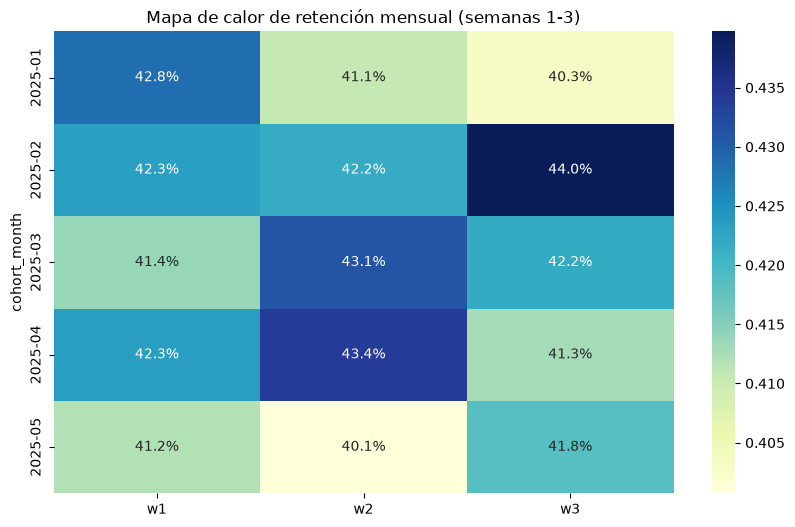

In [23]:
# Calcular los porcentajes
retention_df = cohorte_final.copy()
retention_df['w1'] = retention_df['retenido_w1'] / retention_df['total_usuarios']
retention_df['w2'] = retention_df['retenido_w2'] / retention_df['total_usuarios']
retention_df['w3'] = retention_df['retenido_w3'] / retention_df['total_usuarios']

# 5. Seleccionar solo las columnas de porcentaje
heatmap_data = retention_df[['w1', 'w2', 'w3']]

# 6. Visualizar
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1%', cmap='YlGnBu')
plt.title('Mapa de calor de retención mensual (semanas 1-3)')
plt.show()

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay diferencia significativa entre las tasas de conversión del grupo de control y el grupo de tratamiento. (La nueva interfaz no tiene efecto).
   - **H₁ (Hipótesis alternativa):** Existe una diferencia significativa entre las tasas de conversión del grupo de control y el grupo de tratamiento. (La nueva interfaz sí tiene un efecto).
   
**Test estadístico:** Prueba Z de proporciones (Z-test).

**Nivel de significancia alpha:** 0.05 (Estándar en la industria con un 5% de riesgo de error).

In [24]:
#Importación y muestra de la info
experimento = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
experimento.head(5)

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [25]:
#Importacion de libreria para hacer ztest
from statsmodels.stats.proportion import proportions_ztest

#Separación de datos por grupos
resumen = experimento.groupby('variante')['convirtio'].agg(['sum', 'count'])

#Éxitos
exitos = [resumen.loc['control', 'sum'], resumen.loc['tratamiento', 'sum']]

#Totales
observaciones = [resumen.loc['control', 'count'], resumen.loc['tratamiento', 'count']]

#ztest de proporciones
z_stat, p_value = proportions_ztest(count=exitos, nobs=observaciones)

#Impresión de valores
print(f"Z-stat  : {z_stat:.4f}")
print(f"p-value : {p_value:.6e}")

alpha = 0.05

print(f"p-value: {p_value:.4f}")

if p_value < alpha:
    print("Resultado: Rechazamos la hipótesis nula (H0).")
    print("Conclusión: Existe una diferencia estadísticamente significativa.")
else:
    print("Resultado: No podemos rechazar la hipótesis nula (H0).")
    print("Conclusión: No hay evidencia suficiente para afirmar que hay una diferencia.")

Z-stat  : -0.8133
p-value : 4.160585e-01
p-value: 0.4161
Resultado: No podemos rechazar la hipótesis nula (H0).
Conclusión: No hay evidencia suficiente para afirmar que hay una diferencia.


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [26]:
# link de one drive / google drive
link = "https://drive.google.com/drive/folders/1r3v3NGCElsp8EK_20WXUWsSm7lF0JtDh?usp=sharing"
link

'https://drive.google.com/drive/folders/1r3v3NGCElsp8EK_20WXUWsSm7lF0JtDh?usp=sharing'